In [21]:
# Importing basic libraries for data handling and numerical operations
import pandas as pd
import numpy as np

# Importing dataset loader from sklearn
from sklearn.datasets import fetch_california_housing

# Used to split dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Feature scaling tool to normalize data
from sklearn.preprocessing import StandardScaler

# Machine Learning models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation metrics to measure model performance
from sklearn.metrics import mean_squared_error, r2_score

# Visualization libraries for graphs
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
# Loading the California Housing dataset from sklearn
housing = fetch_california_housing()

# Creating a DataFrame for features (independent variables)
X = pd.DataFrame(housing.data, columns=housing.feature_names)

# Target variable (dependent variable - house price)
y = housing.target

# Display first 5 rows of the dataset
X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [23]:
# Splitting dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Feature Scaling ensures all features have similar scale
# This helps machine learning models perform better

# Creating scaler object
scaler = StandardScaler()

# Fitting scaler on training data and transforming it
X_train_scaled = scaler.fit_transform(X_train)

# Transforming test data using the same scaler
X_test_scaled = scaler.transform(X_test)

In [25]:
# Creating Linear Regression model
lr = LinearRegression()

# Training the model using scaled training data
lr.fit(X_train_scaled, y_train)

# Predicting house prices on test data
y_pred_lr = lr.predict(X_test_scaled)

# Calculating Mean Squared Error
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Calculating R² Score
r2_lr = r2_score(y_test, y_pred_lr)

# Printing results
print("Linear Regression MSE:", mse_lr)
print("Linear Regression R2:", r2_lr)

Linear Regression MSE: 0.5558915986952442
Linear Regression R2: 0.575787706032451


In [26]:
# Ridge Regression is a regularized version of Linear Regression
# It helps reduce overfitting by adding a penalty term

ridge = Ridge(alpha=1.0)

# Training the model
ridge.fit(X_train_scaled, y_train)

# Making predictions
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluating model performance
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# Printing results
print("Ridge Regression MSE:", mse_ridge)
print("Ridge Regression R2:", r2_ridge)

Ridge Regression MSE: 0.5558548589435971
Ridge Regression R2: 0.5758157428913684


In [27]:
# Decision Tree Regressor builds a tree-like model for prediction
# It splits data into branches based on feature values

dt = DecisionTreeRegressor(random_state=42)

# Training the model
dt.fit(X_train_scaled, y_train)

# Making predictions
y_pred_dt = dt.predict(X_test_scaled)

# Evaluating model performance
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Printing results
print("Decision Tree MSE:", mse_dt)
print("Decision Tree R2:", r2_dt)

Decision Tree MSE: 0.5050026039770349
Decision Tree R2: 0.614622142886297


In [28]:
# Random Forest is an ensemble model that combines multiple decision trees
# It usually gives better accuracy than a single tree

rf = RandomForestRegressor(random_state=42)

# Training the model
rf.fit(X_train_scaled, y_train)

# Making predictions
y_pred_rf = rf.predict(X_test_scaled)

# Evaluating model performance
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Printing results
print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 0.2558416902795563
Random Forest R2: 0.80476195254477


In [29]:
# Creating a comparison table for all models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree", "Random Forest"],
    "MSE": [mse_lr, mse_ridge, mse_dt, mse_rf],
    "R2 Score": [r2_lr, r2_ridge, r2_dt, r2_rf]
})

# Display comparison
results

,Model,MSE,R2 Score
0,Linear Regression,0.555892,0.575788
1,Ridge Regression,0.555855,0.575816
2,Decision Tree,0.505003,0.614622
3,Random Forest,0.255842,0.804762


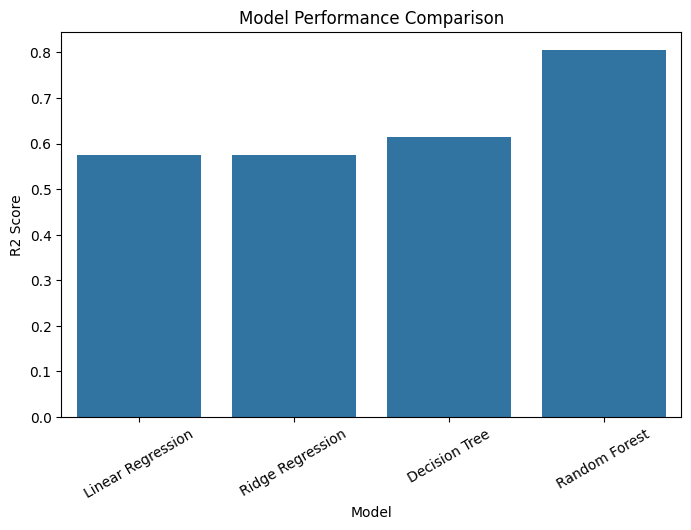

In [30]:
# Visualizing R2 scores of models

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="R2 Score", data=results)

plt.title("Model Performance Comparison")
plt.xticks(rotation=30)

plt.show()

In [31]:
# RMSE (Root Mean Squared Error) gives error in original units
# It is simply the square root of MSE

rmse_lr = np.sqrt(mse_lr)
rmse_ridge = np.sqrt(mse_ridge)
rmse_dt = np.sqrt(mse_dt)
rmse_rf = np.sqrt(mse_rf)

print("Linear Regression RMSE:", rmse_lr)
print("Ridge Regression RMSE:", rmse_ridge)
print("Decision Tree RMSE:", rmse_dt)
print("Random Forest RMSE:", rmse_rf)

Linear Regression RMSE: 0.7455813830127763
Ridge Regression RMSE: 0.7455567442814779
Decision Tree RMSE: 0.7106353523270812
Random Forest RMSE: 0.5058079579045355


In [32]:
# Updated model comparison table including RMSE

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Decision Tree", "Random Forest"],
    "MSE": [mse_lr, mse_ridge, mse_dt, mse_rf],
    "RMSE": [rmse_lr, rmse_ridge, rmse_dt, rmse_rf],
    "R2 Score": [r2_lr, r2_ridge, r2_dt, r2_rf]
})

results

,Model,MSE,RMSE,R2 Score
0,Linear Regression,0.555892,0.745581,0.575788
1,Ridge Regression,0.555855,0.745557,0.575816
2,Decision Tree,0.505003,0.710635,0.614622
3,Random Forest,0.255842,0.505808,0.804762


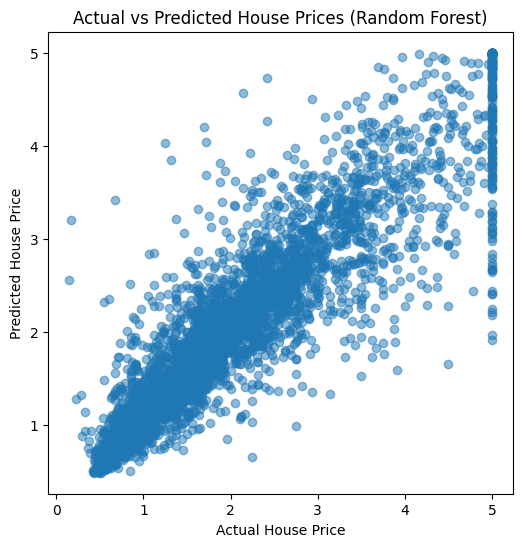

In [33]:
# Plotting Actual vs Predicted values for Random Forest

plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_rf, alpha=0.5)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")

plt.title("Actual vs Predicted House Prices (Random Forest)")

plt.show()

In [34]:
# Extracting feature importance from Random Forest model
# This tells us which features contribute most to the prediction

importances = rf.feature_importances_

# Creating a DataFrame to organize feature importance
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

# Sorting features by importance
feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

# Display top features
feature_importance

,Feature,Importance
0,MedInc,0.524956
5,AveOccup,0.138478
6,Latitude,0.088976
7,Longitude,0.088624
1,HouseAge,0.054517
2,AveRooms,0.044241
4,Population,0.030716
3,AveBedrms,0.029492


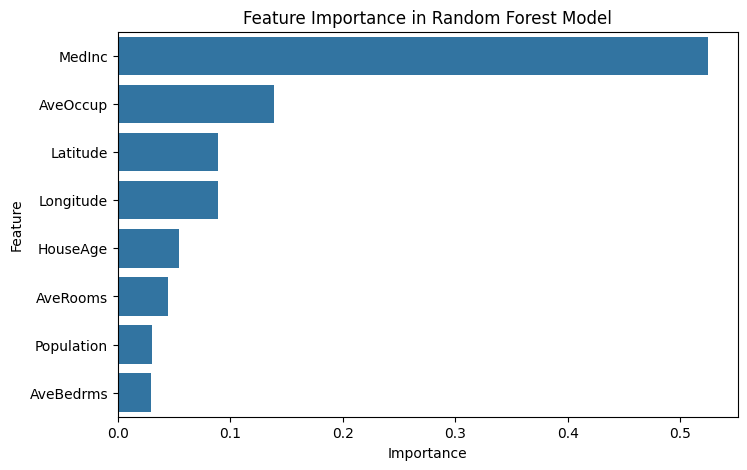

In [35]:
# Visualizing feature importance using bar plot

plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance in Random Forest Model")

plt.show()

#  California Housing Price Prediction – Task 2

# Project Overview
This project focuses on improving and comparing machine learning models for predicting housing prices using the **California Housing Dataset**.

The goal of this task is to apply **feature scaling, train multiple regression models, and evaluate their performance** using different metrics.



# Dataset Information

The dataset used in this project is the **California Housing Dataset** provided by Scikit-Learn.

It contains several features describing housing districts in California.

### Features used:
- *MedInc* → Median income in the area
- *HouseAge* → Median age of houses
- *AveRooms* → Average number of rooms per household
- *AveBedrms* → Average number of bedrooms
- *Population* → Total population in the district
- *AveOccup* → Average number of people per household
- *Latitude* → Geographic latitude
- *Longitude* → Geographic longitude

# Target Variable

- *MedHouseValue* → Median house price


#  Machine Learning Workflow

The following steps were performed to build and evaluate the models:

# Data Loading
The California housing dataset was loaded using **scikit-learn** and converted into a pandas DataFrame.

# Train-Test Split
The dataset was divided into:

- **80% Training Data**
- **20% Testing Data**

This ensures that the model is evaluated on unseen data.

# Feature Scaling
Feature scaling was applied using **StandardScaler** to normalize the range of features.

This step helps machine learning models perform better when features have different scales.


# Machine Learning Models Used

The following regression models were trained and evaluated:

# Linear Regression
A basic regression model that assumes a linear relationship between input features and the target variable.

# Ridge Regression
An improved version of linear regression that includes **regularization** to prevent overfitting.

# Decision Tree Regressor
A tree-based model that splits data into branches based on feature values.

# Random Forest Regressor
An ensemble model that combines multiple decision trees to improve prediction accuracy.


# Model Evaluation Metrics

To evaluate the performance of the models, the following metrics were used:

# Mean Squared Error (MSE)
Measures the average squared difference between predicted and actual values.

# Root Mean Squared Error (RMSE)
The square root of MSE, representing prediction error in the same unit as the target variable.

# R² Score (Coefficient of Determination)
Indicates how well the model explains the variance in the target variable.


# Model Performance

Among all models tested, **Random Forest Regressor performed the best**.

# Random Forest Results

R² Score:

0.804762

This means the model explains approximately **80% of the variance in housing prices**.


#  Visualization

Several visualizations were created to better understand model performance:

- **Model Comparison Graph**
- **Actual vs Predicted Plot**
- **Feature Importance Graph**

The **Actual vs Predicted plot** shows that most predictions follow the diagonal trend, indicating good prediction performance.


#  Feature Importance

Random Forest also provides **feature importance scores**, which indicate which features influence predictions the most.

From the results, **Median Income (MedInc)** appears to be the most important feature affecting housing prices.

This suggests that areas with higher median income generally have higher housing prices.


#  Conclusion

This project demonstrates how multiple machine learning models can be trained and compared for a regression problem.

Key takeaways:

- Feature scaling improves model performance
- Ensemble models like **Random Forest** often outperform simple models
- Visualization helps understand prediction behavior and feature influence

The Random Forest model achieved the best performance with an **R² score of 0.804762**, making it the most suitable model for this task.